In [2]:

import pandas as pd


In [3]:
df = pd.read_csv("dataset/alzheimers_disease_data.csv")

In [4]:
df.columns

Index(['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI',
       'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality',
       'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease',
       'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP',
       'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness', 'Diagnosis', 'DoctorInCharge'],
      dtype='str')

In [5]:
df.drop(columns=['DoctorInCharge' , 'PatientID' ],inplace=True)

In [6]:
df.columns

Index(['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking',
       'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality',
       'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes',
       'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP',
       'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness', 'Diagnosis'],
      dtype='str')

In [7]:
print(df.shape)

(2149, 33)


In [8]:
X = df.drop(columns=["Diagnosis"])
y = df["Diagnosis"]

In [9]:
X.shape


(2149, 32)

In [10]:
y.shape

(2149,)

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify=y , random_state=42)

In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [15]:
from sklearn.linear_model import LogisticRegression


In [16]:
lr  = LogisticRegression(class_weight="balanced")

In [17]:
lr.fit(X_train_scaled , y_train)
y_pred = lr.predict(X_test_scaled)

In [18]:
y_pred.shape

(430,)

In [19]:
from sklearn.metrics import classification_report

In [20]:
report = classification_report(y_test , y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.91      0.79      0.85       278
           1       0.70      0.86      0.77       152

    accuracy                           0.82       430
   macro avg       0.80      0.83      0.81       430
weighted avg       0.83      0.82      0.82       430



## Logistic Regression - Baseline Model Results

### Model Performance
- Overall Accuracy: **82%**
- Alzheimer's Recall: **86%** (catches 86% of actual Alzheimer's patients)
- Alzheimer's Precision: **70%** (some false alarms)
- Alzheimer's F1 Score: **77%**

### Key Observations
- Model correctly identifies most Alzheimer's patients (high recall) 
- But when it predicts Alzheimer's, it's wrong 30% of the time (low precision) 
- Good baseline to beat with Random Forest and XGBoost
- No class_weight used yet — scope to improve

In [21]:
from sklearn.ensemble import RandomForestClassifier

In [22]:
forest  = RandomForestClassifier(class_weight="balanced" , random_state=42)

In [23]:
forest.fit(X_train_scaled , y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [24]:
y_pred = forest.predict(X_test_scaled)

In [25]:
forest_report = classification_report(y_test , y_pred)
print(forest_report)

              precision    recall  f1-score   support

           0       0.92      0.97      0.95       278
           1       0.94      0.85      0.89       152

    accuracy                           0.93       430
   macro avg       0.93      0.91      0.92       430
weighted avg       0.93      0.93      0.93       430



## Random Forest Results vs Logistic Regression

### Random Forest Performance
- Overall Accuracy: **93%** (up from 82%)
- Alzheimer's Recall: **85%** (similar to LR)
- Alzheimer's Precision: **94%** (up from 70%) ✅ huge improvement
- Alzheimer's F1 Score: **89%** (up from 77%)

### Key Observations
- Random Forest significantly outperforms Logistic Regression
- Much fewer false alarms — when it says Alzheimer's, it's right 94% of the time
- Recall slightly dropped but precision jumped massively
- Clear winner so far — XGBoost still to be tested

In [26]:
%pip install xgboost


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import xgboost as xgb

In [28]:
xg = xgb.XGBClassifier(eval_metric='logloss')

In [29]:
xg.fit(X_train_scaled , y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [30]:
xg_pred = xg.predict(X_test_scaled)

In [31]:
report_xg = classification_report(y_test, xg_pred)
print(report)

              precision    recall  f1-score   support

           0       0.91      0.79      0.85       278
           1       0.70      0.86      0.77       152

    accuracy                           0.82       430
   macro avg       0.80      0.83      0.81       430
weighted avg       0.83      0.82      0.82       430



## XGBoost Results (Untuned)
- Accuracy: **82%** | Recall: **86%** | Precision: **70%** | F1: **77%**
- Performs same as Logistic Regression — needs tuning to unlock potential

## All Models Comparison
| Model | Accuracy | Recall | Precision | F1 |
|-------|----------|--------|-----------|----|
| Logistic Regression | 82% | 86% | 70% | 77% |
| Random Forest | 93% | 85% | 94% | 89% |
| XGBoost (untuned) | 82% | 86% | 70%% | 77% |

### ✅ Winner so far → Random Forest

Tuning Xgboost for better performance

In [32]:
parameter_grid ={
     'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 6, 9]
}

In [33]:
from sklearn.model_selection import GridSearchCV


In [34]:
grid_search = GridSearchCV(estimator= xg , param_grid=parameter_grid , cv = 5 , scoring="f1")

In [35]:
grid_search.fit(X_train_scaled , y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 6, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;-

In [36]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 100}
0.9267196921069594


In [37]:
best_model = grid_search.best_estimator_

In [38]:
prediction = best_model.predict(X_test_scaled)

In [39]:
report = classification_report(prediction , y_test)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.94      0.95       286
           1       0.89      0.94      0.91       144

    accuracy                           0.94       430
   macro avg       0.93      0.94      0.93       430
weighted avg       0.94      0.94      0.94       430



## XGBoost Tuned Results

### Performance
- Accuracy: **94%** | Recall: **94%** | Precision: **89%** | F1: **91%**

### Final Model Comparison
| Model | Accuracy | Recall | Precision | F1 |
|-------|----------|--------|-----------|----|
| Logistic Regression | 82% | 86% | 70% | 77% |
| Random Forest | 93% | 85% | 94% | 89% |
| XGBoost (untuned) | 82% | 86% | 70% | 77% |
| XGBoost (tuned) | 94% | 94% | 89% | 91% |

### Winner → XGBoost Tuned
- Highest accuracy and recall across all models
- Recall of 94% means model catches 94% of actual Alzheimer's patients
- Tuning made a massive difference — untuned vs tuned gap is significant

Feature Importance:

In [40]:
best_features = best_model.feature_importances_

In [44]:
best_series = pd.Series(best_features, index=X.columns)

In [45]:
best_series.sort_values(ascending=False)

MemoryComplaints             0.203161
BehavioralProblems           0.143731
FunctionalAssessment         0.119792
MMSE                         0.112113
ADL                          0.103770
Forgetfulness                0.019836
Smoking                      0.017728
CholesterolHDL               0.017041
CardiovascularDisease        0.016482
Age                          0.016040
CholesterolTriglycerides     0.015448
PhysicalActivity             0.014899
BMI                          0.014860
CholesterolLDL               0.014046
DietQuality                  0.013653
CholesterolTotal             0.013203
FamilyHistoryAlzheimers      0.013171
AlcoholConsumption           0.012556
Disorientation               0.012492
SystolicBP                   0.012188
PersonalityChanges           0.011998
Confusion                    0.011879
Depression                   0.011806
SleepQuality                 0.010889
DiastolicBP                  0.010709
EducationLevel               0.010416
Hypertension

In [47]:
top_15 = best_series.nlargest(n = 15)
print(top_15)

MemoryComplaints            0.203161
BehavioralProblems          0.143731
FunctionalAssessment        0.119792
MMSE                        0.112113
ADL                         0.103770
Forgetfulness               0.019836
Smoking                     0.017728
CholesterolHDL              0.017041
CardiovascularDisease       0.016482
Age                         0.016040
CholesterolTriglycerides    0.015448
PhysicalActivity            0.014899
BMI                         0.014860
CholesterolLDL              0.014046
DietQuality                 0.013653
dtype: float32


In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

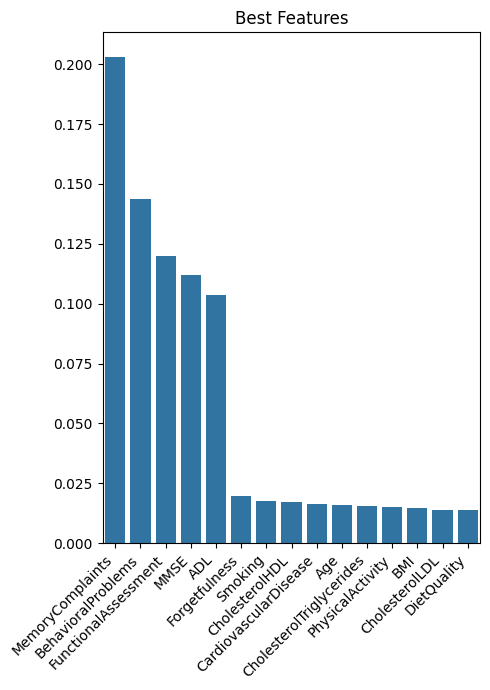

In [61]:
plt.figure(figsize=(5,7))
sns.barplot(top_15)
plt.xticks(rotation=45, ha='right')
plt.title("Best Features")
plt.tight_layout()
plt.show()

In [62]:
import joblib

In [64]:
joblib.dump(best_model , 'alzheimer_model.pkl')


['alzheimer_model.pkl']

In [65]:
joblib.dump(scaler , "scaler.pkl")

['scaler.pkl']